# Khảo sát dữ liệu điện gió tua bin (T1.csv)

Notebook này đọc và khảo sát nhanh dữ liệu tua bin gió. Đây là bước **khảo sát**, chỉ hiển thị kết quả, **không** xuất file dữ liệu.

Các cột trong dữ liệu:
- **Date/Time** — mốc thời gian, 10 phút/lần
- **LV ActivePower (kW)** — công suất thực
- **Wind Speed (m/s)** — tốc độ gió
- **Theoretical_Power_Curve (KWh)** — công suất lý thuyết
- **Wind Direction (°)** — hướng gió

## Bước 1 — Đọc dữ liệu và hiển thị 5 dòng đầu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn tới file dữ liệu (notebook nằm trong Source/, dữ liệu ở Data/input/)
CSV_PATH = "../Data/input/T1.csv"

# Đọc dữ liệu vào DataFrame
df = pd.read_csv(CSV_PATH)

# Hiển thị 5 dòng đầu để xem qua cấu trúc dữ liệu
print("5 dòng đầu của dữ liệu:")
df.head(5)
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn tới file dữ liệu (notebook nằm trong Source/, dữ liệu ở Data/input/)
CSV_PATH = "../Data/input/T1.csv"

# Đọc dữ liệu vào DataFrame
df = pd.read_csv(CSV_PATH)

# Hiển thị 5 dòng đầu để xem qua cấu trúc dữ liệu
print("5 dòng đầu của dữ liệu:")
df.head(5)

ModuleNotFoundError: No module named 'pandas'

## Bước 2 — Số dòng, số cột và kiểu dữ liệu từng cột

In [2]:
# Kích thước dữ liệu: (số dòng, số cột)
so_dong, so_cot = df.shape
print(f"Số dòng: {so_dong}")
print(f"Số cột : {so_cot}")

# Kiểu dữ liệu của từng cột
print("\nKiểu dữ liệu từng cột:")
print(df.dtypes)

Số dòng: 50530
Số cột : 5

Kiểu dữ liệu từng cột:
Date/Time                            str
LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object


## Bước 3 — Thống kê mô tả cho các cột số

In [3]:
# Thống kê mô tả (count, mean, std, min, quartiles, max) cho các cột số
print("Thống kê mô tả các cột số:")
df.describe()

Thống kê mô tả các cột số:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776282,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


## Bước 4 — Kiểm tra chất lượng dữ liệu

- Đếm giá trị thiếu mỗi cột.
- Đếm số dòng có công suất **âm**.
- Đếm số dòng có công suất gần 0 (**< 10 kW**) nhưng tốc độ gió mạnh (**> 5 m/s**) — nghi sự cố tua bin.

In [4]:
# Tên cột dùng lại cho gọn
COT_CONG_SUAT = "LV ActivePower (kW)"
COT_TOC_DO_GIO = "Wind Speed (m/s)"

# (a) Đếm giá trị thiếu mỗi cột
print("Số giá trị thiếu mỗi cột:")
print(df.isnull().sum())

# (b) Đếm số dòng có công suất âm
so_dong_am = (df[COT_CONG_SUAT] < 0).sum()
print(f"\nSố dòng có công suất âm: {so_dong_am}")

# (c) Công suất gần 0 (< 10 kW) nhưng gió mạnh (> 5 m/s) -> nghi sự cố
nghi_su_co = (df[COT_CONG_SUAT] < 10) & (df[COT_TOC_DO_GIO] > 5)
so_dong_nghi = nghi_su_co.sum()
print(f"Số dòng nghi sự cố (công suất < 10 kW nhưng gió > 5 m/s): {so_dong_nghi}")
print(f"Tỷ lệ trên tổng dữ liệu: {so_dong_nghi / len(df) * 100:.2f}%")

Số giá trị thiếu mỗi cột:
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

Số dòng có công suất âm: 57
Số dòng nghi sự cố (công suất < 10 kW nhưng gió > 5 m/s): 1464
Tỷ lệ trên tổng dữ liệu: 2.90%


## Bước 5 — Histogram phân phối tốc độ gió và công suất

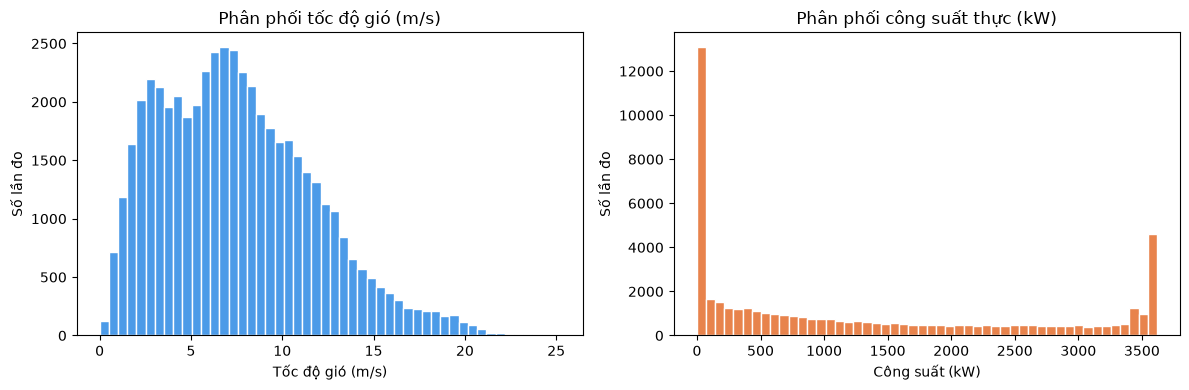

In [5]:
# Vẽ nhanh 2 histogram cạnh nhau để hình dung phân phối dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phân phối tốc độ gió
axes[0].hist(df[COT_TOC_DO_GIO], bins=50, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Phân phối tốc độ gió (m/s)")
axes[0].set_xlabel("Tốc độ gió (m/s)")
axes[0].set_ylabel("Số lần đo")

# Phân phối công suất thực
axes[1].hist(df[COT_CONG_SUAT], bins=50, color="#E8834C", edgecolor="white")
axes[1].set_title("Phân phối công suất thực (kW)")
axes[1].set_xlabel("Công suất (kW)")
axes[1].set_ylabel("Số lần đo")

plt.tight_layout()
plt.show()